# **Data Visualization**

## **Objective**

The objective of this notebook is to transform the analytical findings from the KPI and Business Analysis into clear, meaningful, and visually appealing charts. Using Matplotlib, Seaborn the visualizations highlight accident trends, geographical patterns, time-based variations, weather impacts, road infrastructure characteristics, and accident severity. These visual insights simplify complex data, support data-driven decision-making, and provide a foundation for building an interactive dashboard in the next stage of the project.

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#**Dataset upload**

In [ ]:
df = pd.read_csv('/content/cleaned_road_accident.csv')
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score,severity_index,risk_quartile
0,0,Pune,Maharashtra,18.680826,73.93039,2023-10-22,5:00,5,Sunday,Weekend,...,high,weather,fatal,2,2,Non Peak Hour,No Festival,0.85,4,Q4
1,1,Mumbai,Maharashtra,18.817732,72.79085,2023-05-21,4:00,4,Sunday,Weekend,...,low,weather,major,4,3,Non Peak Hour,No Festival,0.10,12,Q1
2,2,Mumbai,Maharashtra,19.096890,72.81943,2024-07-10,13:00,13,Wednesday,Weekday,...,medium,weather,minor,1,1,Non Peak Hour,No Festival,0.45,1,Q2
3,3,Chandigarh,Punjab,30.787806,76.84750,2025-03-30,11:00,11,Sunday,Weekend,...,high,distraction,minor,5,2,Non Peak Hour,No Festival,0.65,10,Q4
4,4,Chennai,Tamil Nadu,12.965155,80.28331,2024-01-25,16:00,16,Thursday,Weekday,...,low,distraction,minor,2,1,Non Peak Hour,No Festival,0.10,2,Q1


**Q1. Donut Chart showing the percentage of accident severity (Fatal, Major, Minor).**

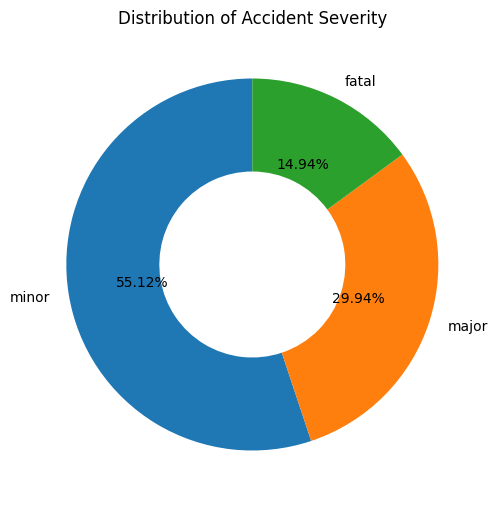

In [ ]:
severity = df['accident_severity'].value_counts().reset_index()
severity.columns = ['accident_severity','total_accident']

plt.figure(figsize=(6,7))
plt.pie(x = severity['total_accident'],
        labels=severity['accident_severity'],
        autopct='%0.2f%%',
        startangle=90,
        wedgeprops={'width':0.5})
plt.title('Distribution of Accident Severity')
plt.show()

**Q2. compare accident counts across all states.**

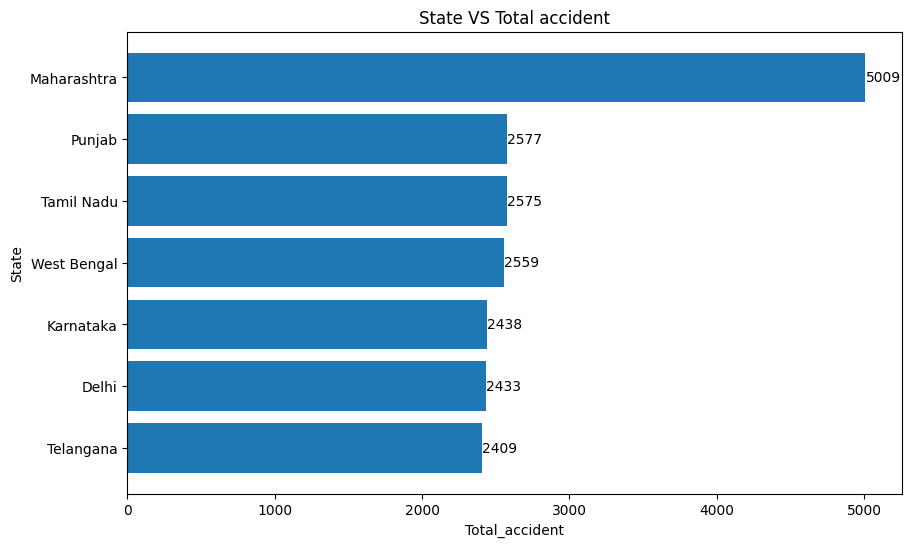

In [ ]:
state_accident = df.groupby('state').agg(
    total_accidents = ('accident_id','count')
).reset_index()

state_accident = state_accident.sort_values(
    by='total_accidents',
    ascending=True
)

plt.figure(figsize=(10,6))
plt.barh(state_accident['state'],state_accident['total_accidents'])
plt.xlabel('Total_accident')
plt.ylabel('State')
plt.title('State VS Total accident')
for i, value in enumerate(state_accident['total_accidents']):
    plt.text(value, i, str(value), va='center')
plt.show()

**Q3. which cities have the highest number of fatal accidents.**

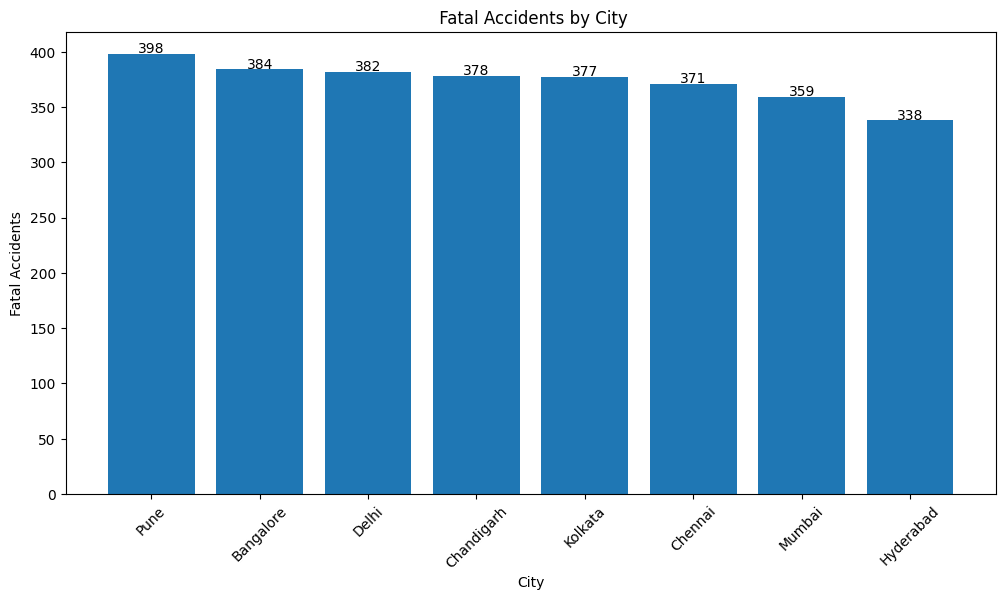

In [ ]:
fatal_accident = df[df['accident_severity']=='fatal'].groupby('city').agg(
    fatal_accidents = ('accident_severity','count')
).reset_index()
fatal_accident = fatal_accident.sort_values(by='fatal_accidents',ascending=False)

plt.figure(figsize=(12,6))
plt.bar(fatal_accident['city'],fatal_accident['fatal_accidents'])
plt.xlabel('City')
plt.ylabel('Fatal Accidents')
plt.title(' Fatal Accidents by City')
plt.xticks(rotation=45)

for i, value in enumerate(fatal_accident['fatal_accidents']):
  plt.text(i, value + 1, str(value), ha='center')
plt.show()

**Q4. how accident frequency changes throughout the day.**

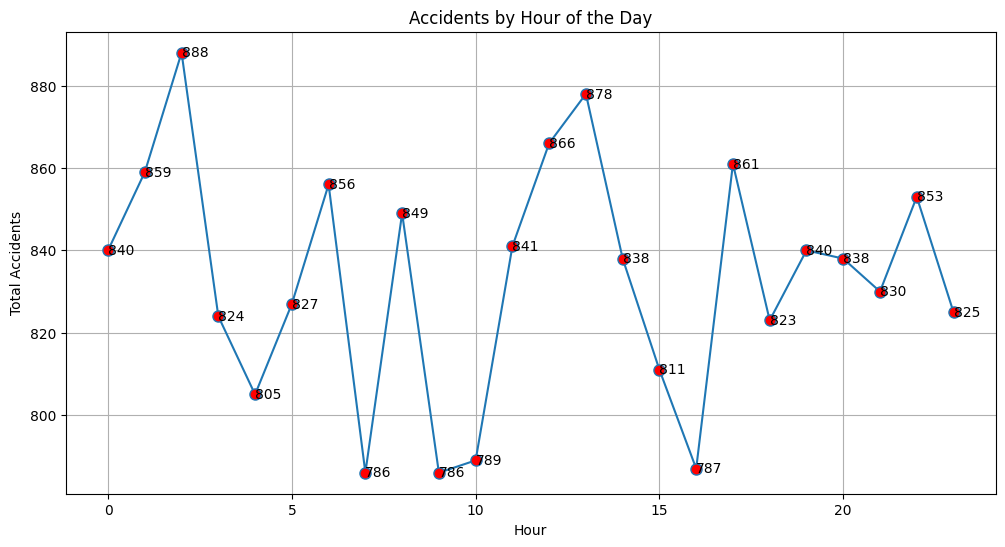

In [ ]:
hour_accident = df.groupby('hour').agg(
    total_accidents = ('accident_id','count')
).reset_index()

plt.figure(figsize=(12,6))
plt.plot(hour_accident['hour'],hour_accident['total_accidents']
         ,marker='o',mfc='red',markersize=8)
plt.grid()
plt.xlabel('Hour')
plt.ylabel('Total Accidents')
plt.title('Accidents by Hour of the Day')

for i,value in enumerate(hour_accident['total_accidents']):
  plt.text(i,value,str(value),va='center',color='black')
plt.show()

**Q5. compare accident distribution between weekdays and weekends.**

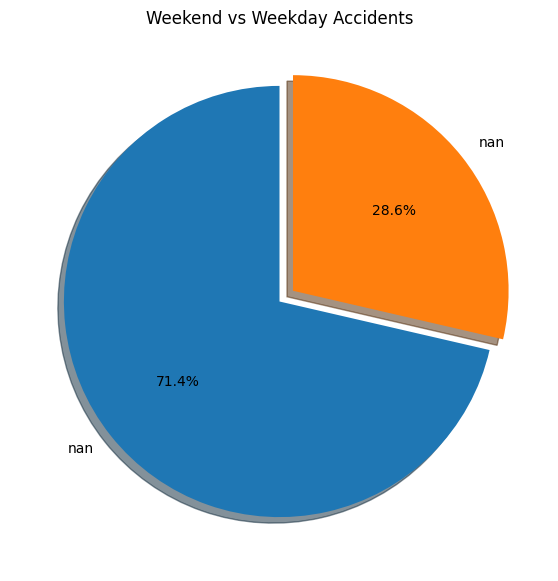

In [ ]:
weekend_accident = df.groupby('is_weekend').agg(
    total_accidents = ('accident_id','count')
).reset_index()
weekend_accident['is_weekend'] = weekend_accident['is_weekend'].map({
    0: 'Weekday',
    1: 'Weekend'
})

plt.figure(figsize=(7,7))
plt.pie(weekend_accident['total_accidents'],
        labels=weekend_accident['is_weekend'],
        autopct='%0.1f%%',
        explode=[0,0.08],
        shadow=True,
        startangle=90
        )
plt.title('Weekend vs Weekday Accidents')
plt.show()

**Q6. Count Plot for accidents by day of the week.**

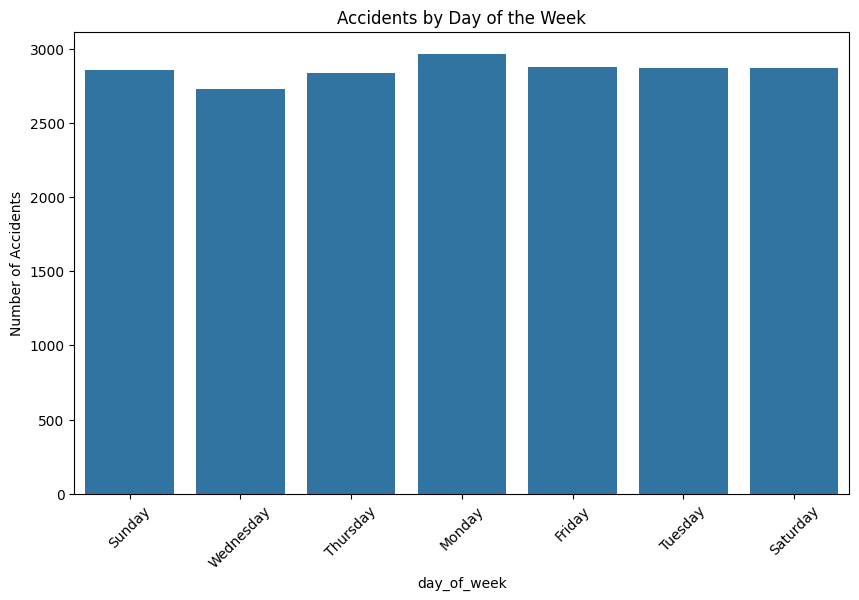

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x=df['day_of_week'])
plt.xticks(rotation=45)
plt.ylabel("Number of Accidents")
plt.title('Accidents by Day of the Week')
plt.show()

**Q7. how accident severity varies under different weather conditions.**

Text(0.5, 1.0, 'Weather vs Accident Severity')

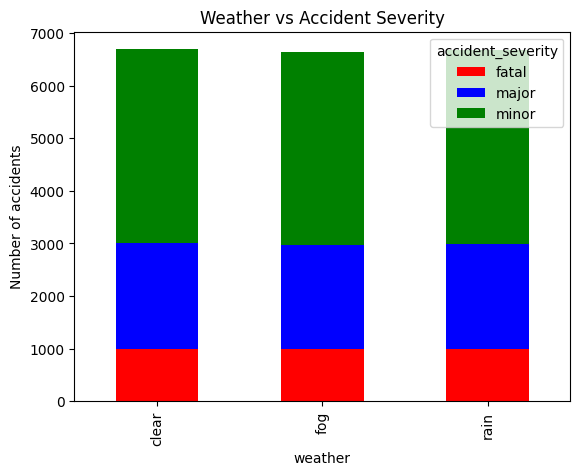

In [ ]:
weather_accident = pd.crosstab(
    df['weather'],
    df['accident_severity']
)

weather_accident.plot(kind='bar', stacked=True,color=['red','blue','green'])

plt.ylabel('Number of accidents')
plt.title('Weather vs Accident Severity')

**Q8. which combinations of traffic density and accident severity occur most frequently.**

Text(0.5, 1.0, 'Traffic Density vs Accident Severity')

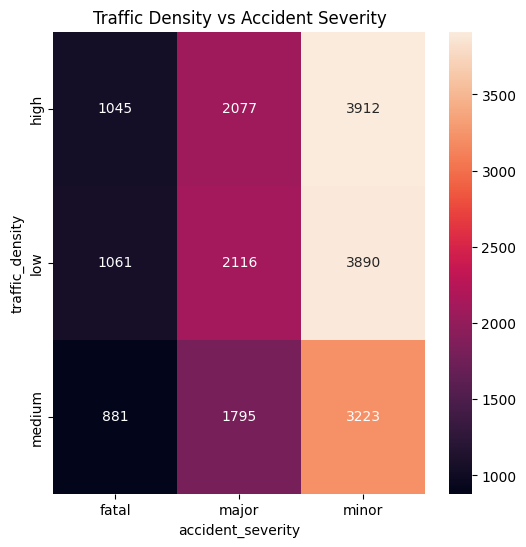

In [ ]:
traffic_accident = pd.crosstab(
    df['traffic_density'],
    df['accident_severity']
)

plt.figure(figsize=(6,6))
sns.heatmap(data = traffic_accident,annot=True,fmt='d')
plt.title('Traffic Density vs Accident Severity')

**Q9. how the risk score varies across accident severity levels.**

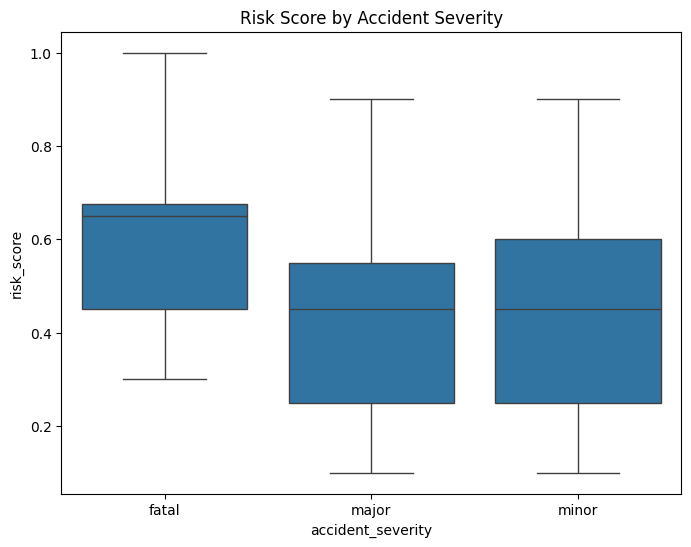

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['accident_severity'],y=df['risk_score'],)
plt.title('Risk Score by Accident Severity')
plt.show()

**Q10. overall distribution of risk scores across all accidents.**

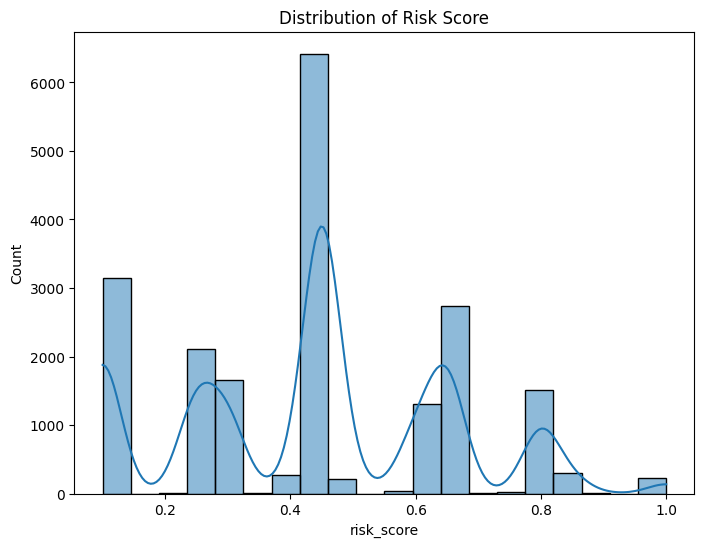

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(x=df['risk_score'],bins=20,kde=True)
plt.title('Distribution of Risk Score')
plt.show()

**Q11. whether accidents involving more vehicles tend to result in more casualties.**

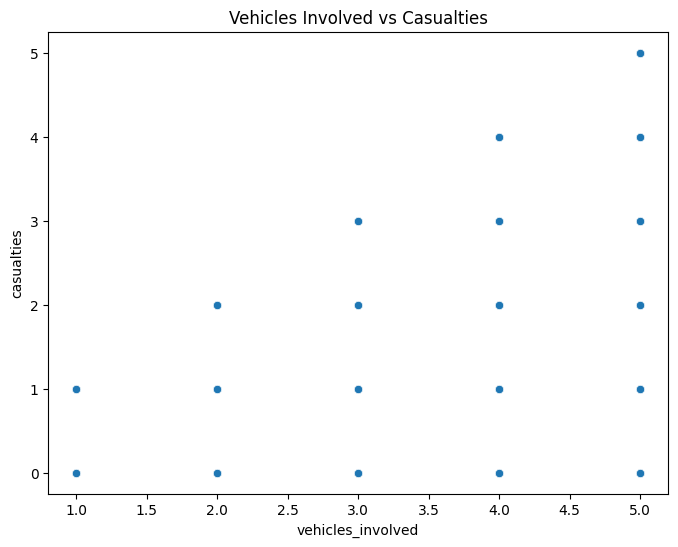

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['vehicles_involved'],y=df['casualties'])
plt.title('Vehicles Involved vs Casualties')
plt.show()

**Q12. compare the average risk score across different weather conditions.**

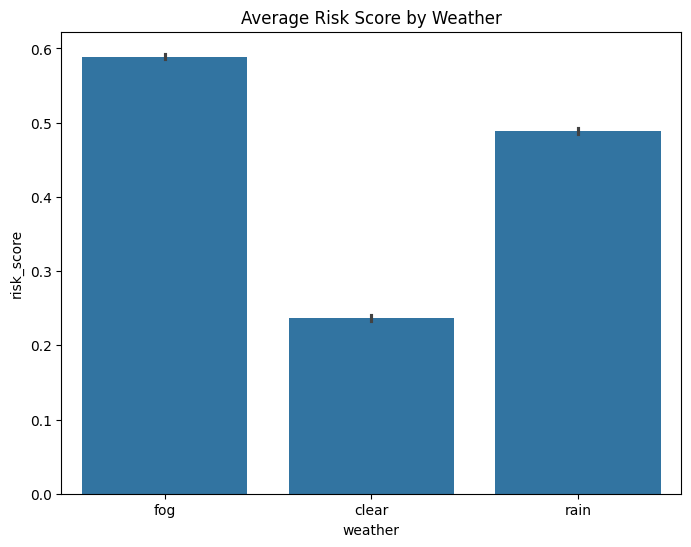

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x=df['weather'],y= df['risk_score'])
plt.title('Average Risk Score by Weather')
plt.show()

**Q13. Create a Violin Plot showing the distribution of risk scores across different weather conditions.**

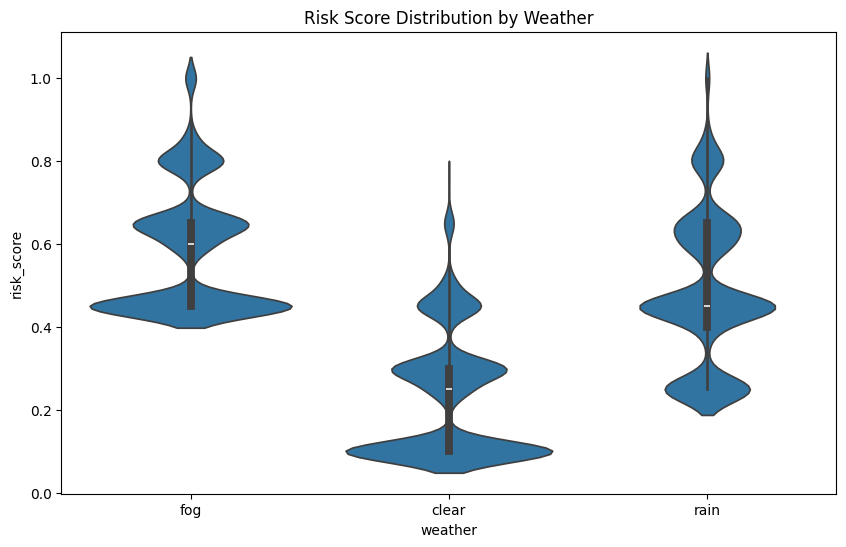

In [ ]:
plt.figure(figsize=(10,6))
sns.violinplot(df,x='weather',y='risk_score')
plt.title('Risk Score Distribution by Weather')
plt.show()

**Q14.whether higher temperatures are associated with higher accident risk.**

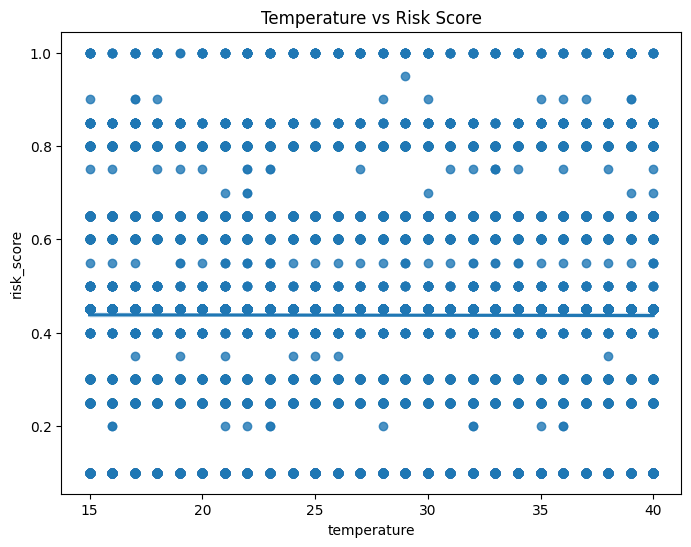

In [ ]:
plt.figure(figsize=(8,6))
plt.title('Temperature vs Risk Score')
sns.regplot(data=df, x='temperature',y='risk_score')
plt.show()

**temperature alone is not a strong predictor of accident risk score.**

**Q15. compare the average casualties under different traffic density levels.**

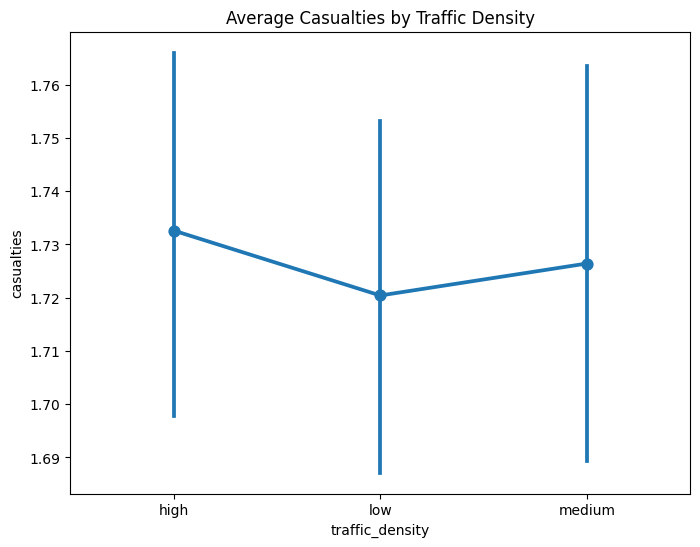

In [ ]:
plt.figure(figsize=(8,6))
plt.title('Average Casualties by Traffic Density')
sns.pointplot(data=df, x='traffic_density',y='casualties')
plt.show()

**Q16. how risk scores change with visibility under different weather conditions.**

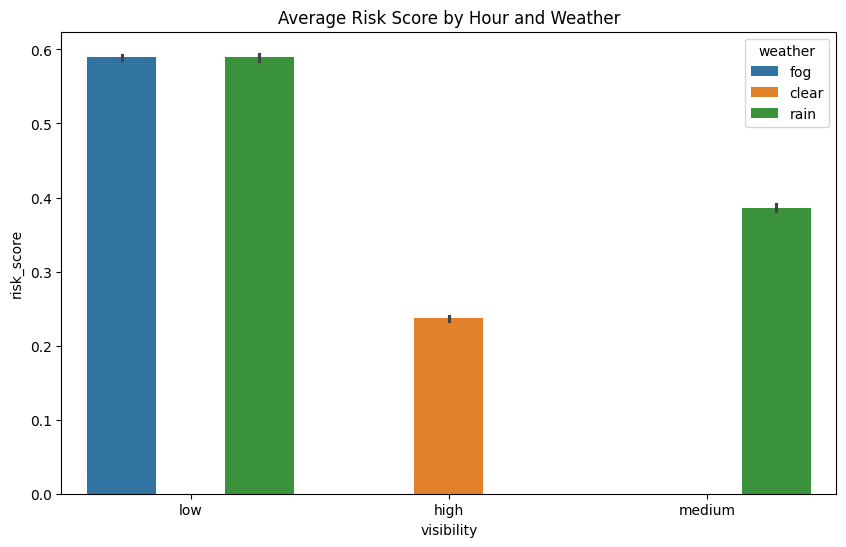

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Average Risk Score by Hour and Weather')
sns.barplot(data=df, x='visibility',y='risk_score',hue='weather')
plt.show()

**Q17. how accident severity is distributed across different states.**

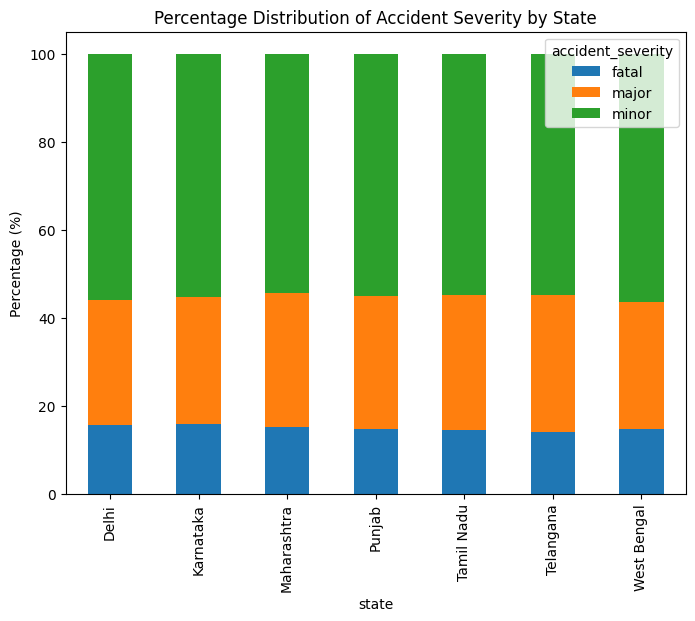

In [ ]:
percentage_accident = pd.crosstab(df['state'],df['accident_severity'],normalize='index')*100

percentage_accident.plot(kind='bar',
                         stacked = True,
                         title='Percentage Distribution of Accident Severity by State',
                         figsize=(8,6)
                         )
plt.ylabel("Percentage (%)")
plt.show()

**Q18. how the average risk score changes throughout the day under different weather conditions.**

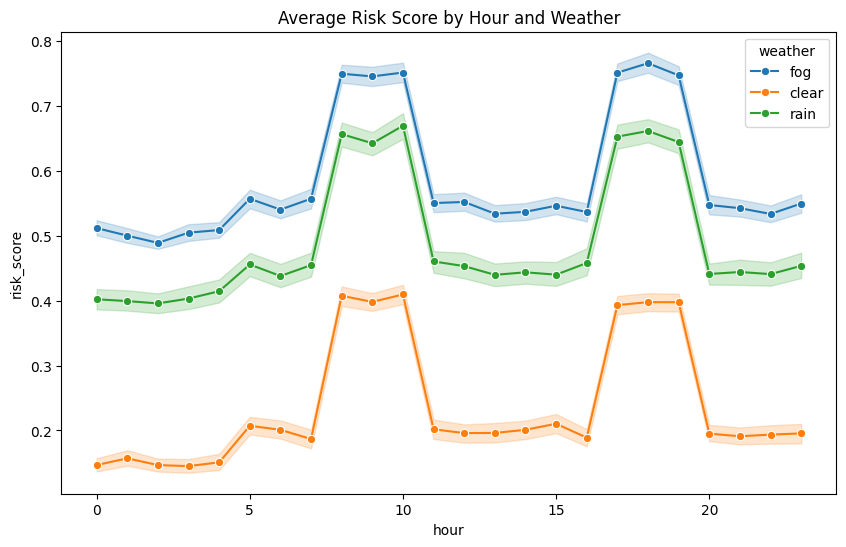

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Average Risk Score by Hour and Weather')
sns.lineplot(data=df, x='hour',y='risk_score',hue='weather',marker='o')
plt.show()

**Q19. whether accidents involving more vehicles also result in higher risk scores under different weather conditions.**

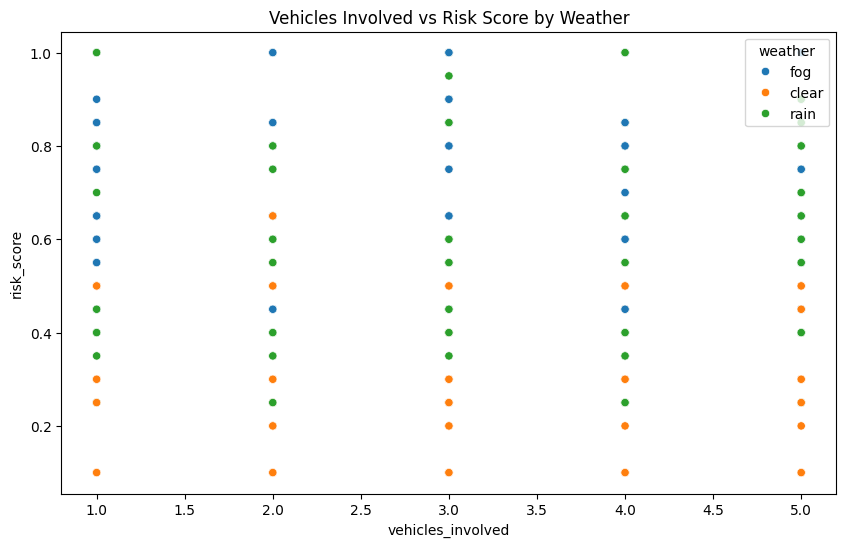

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Vehicles Involved vs Risk Score by Weather')
sns.scatterplot(data=df, x='vehicles_involved',y='risk_score',hue='weather',marker='o')
plt.show()

**Q20. compares average risk scores across:**

- **Different days of the week**
- **Different weather conditions**

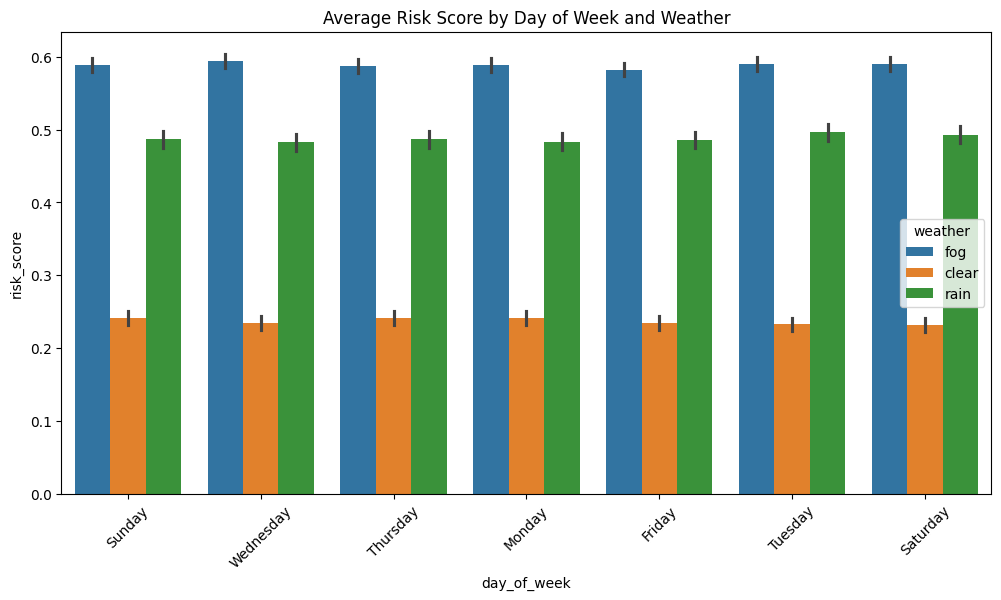

In [ ]:
plt.figure(figsize=(12,6))
plt.title('Average Risk Score by Day of Week and Weather')
sns.barplot(data=df, x='day_of_week',y='risk_score',hue='weather')
plt.xticks(rotation=45)
plt.show()